In [1]:
!pip install --no-index --find-links \
    /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels \
    arc-agi python-dotenv

!mkdir -p pillow-wheelhouse

!python -m pip download \
  --only-binary=:all: \
  --platform manylinux_2_28_x86_64 \
  --python-version 312 \
  --implementation cp \
  --abi cp312 \
  -d pillow-wheelhouse \
  "Pillow==11.3.0"

import os
os.environ["ARC_API_KEY"] = "8276b267-673b-4042-86a7-10badc300bd8"

os.environ["LOCAL_VLM_MODEL_PATH"] = "/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/8b-instruct/1"

Looking in links: /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arc_agi-0.9.8-py3-none-any.whl
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arcengine-0.9.3-py3-none-any.whl (from arc-agi)
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from arc-agi)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatib

In [15]:
# =========================
# 1. Config
# =========================

import os
from pathlib import Path

CONFIG = {
    "MODEL_PATH": os.getenv(
        "LOCAL_VLM_MODEL_PATH",
        "/kaggle/input/models/qwen-lm/qwen-3-vl/transformers/8b-instruct/1",
    ),
    "GAME_ID": os.getenv("ARC_GAME_ID", "su15"),
    "ARC_MODE": os.getenv("ARC_MODE", "online"),  # offline | online | competition
    "ARC_API_KEY": os.getenv("ARC_API_KEY", ""),
    "ARC_BASE_URL": os.getenv(
        "ARC_BASE_URL",
        "http://gateway:8001" if os.getenv("KAGGLE_IS_COMPETITION_RERUN") else "https://three.arcprize.org",
    ),
    "ENVIRONMENTS_DIR": os.getenv(
        "ARC_ENVIRONMENTS_DIR",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files",
    ),
    "RECORDINGS_DIR": os.getenv("ARC_RECORDINGS_DIR", "/kaggle/working/recordings"),
    "LOG_PATH": os.getenv("ARC_VLM_LOG_PATH", "/kaggle/working/vlm_policy_run.jsonl"),
    "SUMMARY_PATH": os.getenv("ARC_VLM_SUMMARY_PATH", "/kaggle/working/vlm_policy_summary.json"),

    "MAX_STEPS": int(os.getenv("ARC_VLM_MAX_STEPS", "30")),
    "MAX_NEW_TOKENS": int(os.getenv("ARC_VLM_MAX_NEW_TOKENS", "850")),
    "IMAGE_SCALE": int(os.getenv("ARC_VLM_IMAGE_SCALE", "8")),
    "DRAW_GRID": os.getenv("ARC_VLM_DRAW_GRID", "1") == "0",
    "PRINT_VLM_OUTPUT": os.getenv("ARC_VLM_PRINT_OUTPUT", "1") == "1",

    "ALLOW_DOWNLOAD": os.getenv("ALLOW_MODEL_DOWNLOAD", "0") == "1",
    "FORCE_RELOAD_MODEL": False,
    "SAVE_RECORDING": os.getenv("ARC_SAVE_RECORDING", "1") == "1",
}
CONFIG

# Multi-action planning controls
CONFIG["ACTIONS_PER_VLM_CALL"] = int(os.getenv("ARC_VLM_ACTIONS_PER_CALL", "3"))

# Whether to stop queued actions early when something important changes
CONFIG["STOP_SEQUENCE_ON_NO_CHANGE"] = True
CONFIG["STOP_SEQUENCE_ON_LEVEL_CHANGE"] = True
CONFIG["STOP_SEQUENCE_ON_ACTIONS_CHANGE"] = True

In [16]:
# =========================
# 0. Offline Pillow fix — run first
# =========================

import os
import sys
import site
import shutil
import subprocess
from pathlib import Path

PILLOW_WHEEL_DIRS = [
    Path(os.getenv("PILLOW_WHEEL_DIR", "")) if os.getenv("PILLOW_WHEEL_DIR") else None,
    Path("/kaggle/input/pillow-wheelhouse"),
    Path("/kaggle/working/pillow-wheelhouse"),
]
PILLOW_WHEEL_DIRS = [p for p in PILLOW_WHEEL_DIRS if p is not None]

def clean_existing_pillow():
    candidates = []
    for base in site.getsitepackages():
        base = Path(base)
        candidates += list(base.glob("PIL"))
        candidates += list(base.glob("Pillow-*.dist-info"))
        candidates += list(base.glob("pillow-*.dist-info"))

    user_site = Path(site.getusersitepackages())
    candidates += list(user_site.glob("PIL"))
    candidates += list(user_site.glob("Pillow-*.dist-info"))
    candidates += list(user_site.glob("pillow-*.dist-info"))

    for path in candidates:
        if path.exists():
            print("Removing:", path)
            shutil.rmtree(path, ignore_errors=True)

    for name in list(sys.modules):
        if name == "PIL" or name.startswith("PIL."):
            sys.modules.pop(name, None)

def find_pillow_wheel():
    wheels = []
    for d in PILLOW_WHEEL_DIRS:
        if d.exists():
            wheels += sorted(d.glob("Pillow-*.whl"))
            wheels += sorted(d.glob("pillow-*.whl"))
    if not wheels:
        return None

    prefer = [w for w in wheels if "11.3.0" in w.name]
    return prefer[0] if prefer else wheels[0]

def install_pillow_from_local_wheel():
    wheel = find_pillow_wheel()
    if wheel is None:
        print("WARNING: no local Pillow wheel found. Using preinstalled Pillow.")
    else:
        print("Installing Pillow from local wheel:", wheel)
        clean_existing_pillow()
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-index",
            "--no-deps",
            "--force-reinstall",
            str(wheel),
            "-q",
        ])

        for name in list(sys.modules):
            if name == "PIL" or name.startswith("PIL."):
                sys.modules.pop(name, None)

    import PIL
    from PIL import Image, ImageDraw, ImageFont, ImageColor
    print("Pillow OK:", PIL.__version__)
    print("Pillow file:", PIL.__file__)

install_pillow_from_local_wheel()

Installing Pillow from local wheel: /kaggle/working/pillow-wheelhouse/pillow-11.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
Removing: /usr/local/lib/python3.12/dist-packages/PIL
Removing: /usr/local/lib/python3.12/dist-packages/pillow-12.2.0.dist-info
Pillow OK: 11.3.0
Pillow file: /usr/local/lib/python3.12/dist-packages/PIL/__init__.py


In [4]:
# =========================
# 2. Imports and paths
# =========================

import sys
import json
import re
import time
import shutil
import tempfile
from pprint import pprint
from pathlib import Path
from collections import deque

import numpy as np
import torch

IN_KAGGLE = Path("/kaggle/input").exists()
REPO_ROOT = Path(os.getenv("AGI_ARC_REPO", "/kaggle/working/agi-arc" if IN_KAGGLE else Path.cwd()))

COMP_ROOT = Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3")
wheel_dir = COMP_ROOT / "arc_agi_3_wheels"
if IN_KAGGLE and wheel_dir.exists():
    print("Installing arc-agi from competition wheels...")
    get_ipython().system(f"pip install --no-index --find-links {wheel_dir} arc-agi python-dotenv -q")

for candidate in [
    REPO_ROOT / "src",
    Path.cwd() / "src",
    Path("/kaggle/working/agi-arc/src"),
]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

Path(CONFIG["RECORDINGS_DIR"]).mkdir(parents=True, exist_ok=True)

print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
try:
    import transformers
    print("transformers:", transformers.__version__)
except Exception as exc:
    print("transformers import failed:", repr(exc))

print("repo root:", REPO_ROOT)

Installing arc-agi from competition wheels...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
python: 3.12.12
torch: 2.10.0+cu128
transformers: 5.0.0
repo root: /kaggle/working/agi-arc


In [5]:
# =========================
# 3. Model loading helpers
# =========================

def resolve_model_path(model_path):
    p = Path(model_path).expanduser()
    if (p / "config.json").exists():
        return p

    hits = list(p.rglob("config.json")) if p.exists() else []
    hits = [x.parent for x in hits]
    if len(hits) == 1:
        return hits[0]

    if not p.exists():
        raise FileNotFoundError(f"MODEL_PATH does not exist: {p}")

    raise FileNotFoundError(
        f"Could not resolve model dir from {p}. Found {len(hits)} config.json files: {hits[:10]}"
    )

def _read_json(path, default=None):
    path = Path(path)
    if not path.exists():
        return {} if default is None else default
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def _write_json(path, obj):
    with Path(path).open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def make_symlink_tree(src_dir, dst_dir):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    for item in src_dir.iterdir():
        target = dst_dir / item.name
        if target.exists() or target.is_symlink():
            continue
        try:
            target.symlink_to(item, target_is_directory=item.is_dir())
        except Exception:
            if item.is_file() and item.stat().st_size < 20_000_000:
                shutil.copy2(item, target)

def patched_qwen3vl_processor_dir(model_path):
    model_path = Path(model_path)
    tmp = Path(tempfile.mkdtemp(prefix="qwen3vl_processor_patch_"))
    make_symlink_tree(model_path, tmp)

    processor_config = _read_json(model_path / "processor_config.json", {})
    processor_config["processor_class"] = "Qwen3VLProcessor"
    processor_config.setdefault("image_processor_type", "Qwen3VLImageProcessor")
    processor_config["video_processor_type"] = "Qwen3VLVideoProcessor"
    _write_json(tmp / "processor_config.json", processor_config)

    preprocessor_config = _read_json(model_path / "preprocessor_config.json", {})
    preprocessor_config.setdefault("image_processor_type", "Qwen3VLImageProcessor")
    preprocessor_config["video_processor_type"] = "Qwen3VLVideoProcessor"
    _write_json(tmp / "preprocessor_config.json", preprocessor_config)

    video_config = _read_json(model_path / "video_preprocessor_config.json", None)
    if not video_config:
        video_config = dict(preprocessor_config)
    video_config["video_processor_type"] = "Qwen3VLVideoProcessor"
    video_config.pop("image_processor_type", None)
    _write_json(tmp / "video_preprocessor_config.json", video_config)

    print("patched processor dir:", tmp)
    return tmp

In [6]:
# =========================
# 4. Load Qwen3-VL once
# =========================

VLM_STATE = {
    "processor": None,
    "model": None,
    "model_path": None,
    "processor_path": None,
}

def load_qwen3_vl(model_path):
    from transformers import AutoConfig, AutoProcessor
    try:
        from transformers import Qwen3VLForConditionalGeneration
    except Exception:
        from transformers.models.qwen3_vl.modeling_qwen3_vl import Qwen3VLForConditionalGeneration

    model_path = resolve_model_path(model_path)
    local_only = not CONFIG.get("ALLOW_DOWNLOAD", False)
    print("resolved model_path =", model_path)

    config = AutoConfig.from_pretrained(
        str(model_path),
        trust_remote_code=True,
        local_files_only=local_only,
    )
    print("model_type:", getattr(config, "model_type", None), "architectures:", getattr(config, "architectures", None))

    processor_path = model_path
    try:
        processor = AutoProcessor.from_pretrained(
            str(processor_path),
            trust_remote_code=True,
            local_files_only=local_only,
            use_fast=False,
        )
        print("AutoProcessor loaded from original model path")
    except Exception as exc:
        print("AutoProcessor original load failed:", repr(exc))
        print("Trying patched processor config directory...")
        processor_path = patched_qwen3vl_processor_dir(model_path)
        for module_name in list(sys.modules):
            if module_name.startswith("transformers.models.qwen3_vl.processing_qwen3_vl"):
                sys.modules.pop(module_name, None)

        processor = AutoProcessor.from_pretrained(
            str(processor_path),
            trust_remote_code=True,
            local_files_only=local_only,
            use_fast=False,
        )
        print("AutoProcessor loaded from patched processor path")

    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    kwargs = dict(
        trust_remote_code=True,
        local_files_only=local_only,
        low_cpu_mem_usage=True,
        torch_dtype=dtype,
    )
    if torch.cuda.is_available():
        kwargs["device_map"] = "auto"

    model = Qwen3VLForConditionalGeneration.from_pretrained(str(model_path), **kwargs)
    model.eval()

    print("loaded processor:", type(processor).__name__)
    print("loaded model:", type(model).__name__)
    return processor, model, str(model_path), str(processor_path)

def get_or_load_vlm(force_reload=None):
    if force_reload is None:
        force_reload = CONFIG.get("FORCE_RELOAD_MODEL", False)

    if (
        not force_reload
        and VLM_STATE["processor"] is not None
        and VLM_STATE["model"] is not None
    ):
        print("using cached VLM:", VLM_STATE["model_path"])
        return VLM_STATE["processor"], VLM_STATE["model"]

    processor, model, model_path, processor_path = load_qwen3_vl(CONFIG["MODEL_PATH"])
    VLM_STATE["processor"] = processor
    VLM_STATE["model"] = model
    VLM_STATE["model_path"] = model_path
    VLM_STATE["processor_path"] = processor_path
    return processor, model

processor, model = get_or_load_vlm()

resolved model_path = /kaggle/input/models/qwen-lm/qwen-3-vl/transformers/8b-instruct/1
model_type: qwen3_vl architectures: ['Qwen3VLForConditionalGeneration']
AutoProcessor loaded from original model path


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

loaded processor: Qwen3VLProcessor
loaded model: Qwen3VLForConditionalGeneration


In [17]:
# =========================
# 5. Grid / frame helpers
# =========================

ARC_PALETTE_RGB = {
    0: (0xFF, 0xFF, 0xFF),  # White
    1: (0xCC, 0xCC, 0xCC),  # Off-white
    2: (0x99, 0x99, 0x99),  # Neutral light
    3: (0x66, 0x66, 0x66),  # Neutral
    4: (0x33, 0x33, 0x33),  # Off-black
    5: (0x00, 0x00, 0x00),  # Black
    6: (0xE5, 0x3A, 0xA3),  # Magenta
    7: (0xFF, 0x7B, 0xCC),  # Magenta light
    8: (0xF9, 0x3C, 0x31),  # Red
    9: (0x1E, 0x93, 0xFF),  # Blue
    10: (0x88, 0xD8, 0xF1), # Blue light
    11: (0xFF, 0xDC, 0x00), # Yellow
    12: (0xFF, 0x85, 0x1B), # Orange
    13: (0x92, 0x12, 0x31), # Maroon
    14: (0x4F, 0xCC, 0x30), # Green
    15: (0xA3, 0x56, 0xD6), # Purple
}

def as_list_grid(grid):
    if grid is None:
        return []
    if hasattr(grid, "tolist"):
        grid = grid.tolist()
    return [[int(cell) for cell in row] for row in grid]

def raw_frame_stack(raw_frame):
    return list(getattr(raw_frame, "frame", []) or [])

def latest_grid_from_raw(raw_frame):
    frames = raw_frame_stack(raw_frame)
    return as_list_grid(frames[-1]) if frames else []

def grid_to_rgb_array(grid, scale=None, draw_grid=None):
    if scale is None:
        scale = CONFIG["IMAGE_SCALE"]
    if draw_grid is None:
        draw_grid = CONFIG["DRAW_GRID"]

    arr = np.asarray(as_list_grid(grid), dtype=np.int64)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D grid, got shape={arr.shape}")

    h, w = arr.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for color, value in ARC_PALETTE_RGB.items():
        rgb[arr == color] = value

    if scale and scale > 1:
        rgb = np.repeat(np.repeat(rgb, scale, axis=0), scale, axis=1)

    if draw_grid and scale and scale >= 6:
        rgb[::scale, :, :] = 40
        rgb[:, ::scale, :] = 40

    return rgb.astype(np.uint8)

def summarize_grid(grid):
    grid = as_list_grid(grid)
    if not grid:
        return {"shape": [0, 0], "colors": [], "nonzero": 0}
    arr = np.asarray(grid, dtype=int)
    return {
        "shape": [int(x) for x in arr.shape],
        "colors": [int(x) for x in sorted(np.unique(arr).tolist())],
        "nonzero": int(np.count_nonzero(arr)),
    }

def summarize_objects(grid, max_objects=10):
    arr = np.asarray(as_list_grid(grid), dtype=int)
    if arr.ndim != 2 or arr.size == 0:
        return []

    h, w = arr.shape
    seen = np.zeros((h, w), dtype=bool)
    objects = []

    for y0 in range(h):
        for x0 in range(w):
            if seen[y0, x0]:
                continue

            color = int(arr[y0, x0])
            seen[y0, x0] = True
            if color == 0:
                continue

            q = deque([(x0, y0)])
            cells = []

            while q:
                x, y = q.popleft()
                cells.append((x, y))
                for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < w and 0 <= ny < h:
                        if not seen[ny, nx] and int(arr[ny, nx]) == color:
                            seen[ny, nx] = True
                            q.append((nx, ny))

            xs = [c[0] for c in cells]
            ys = [c[1] for c in cells]
            objects.append({
                "color_id": color,
                "cell_count": len(cells),
                "bbox": {
                    "x_min": int(min(xs)),
                    "x_max": int(max(xs)),
                    "y_min": int(min(ys)),
                    "y_max": int(max(ys)),
                },
                "center": {
                    "x": round(float(sum(xs) / len(xs)), 2),
                    "y": round(float(sum(ys) / len(ys)), 2),
                },
                "size": [int(max(xs) - min(xs) + 1), int(max(ys) - min(ys) + 1)],
            })

    objects.sort(key=lambda o: o["cell_count"], reverse=True)
    return objects[:max_objects]

def display_grid(grid, scale=None, title=None):
    rgb = grid_to_rgb_array(grid, scale=scale or 6, draw_grid=True)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(5, 5))
        plt.imshow(rgb)
        plt.axis("off")
        if title:
            plt.title(title)
        plt.show()
    except Exception as exc:
        print("display failed:", repr(exc))
        print("grid summary:", summarize_grid(grid))

def normalize_action_name(action_obj):
    name = getattr(action_obj, "name", None)
    s = str(name) if name else str(action_obj)

    if s.startswith("ACTION"):
        return s

    m = re.search(r"ACTION\s*([0-9]+)", s)
    if m:
        return f"ACTION{m.group(1)}"

    if s.strip().isdigit():
        return f"ACTION{s.strip()}"

    m = re.fullmatch(r"[A-Za-z]*\(?([0-9]+)\)?", s.strip())
    if m:
        return f"ACTION{m.group(1)}"

    return s

def available_action_names(raw_frame):
    actions = list(getattr(raw_frame, "available_actions", []) or [])
    names = [normalize_action_name(a) for a in actions]
    return [x for x in names if x]

def frame_metadata(raw_frame, game_id=None):
    grid = latest_grid_from_raw(raw_frame)
    state = getattr(raw_frame, "state", None)
    state_name = getattr(state, "name", str(state)) if state is not None else None

    return {
        "game_id": game_id,
        "state": state_name,
        "available_actions": available_action_names(raw_frame),
        "levels_completed": getattr(raw_frame, "levels_completed", None),
        "win_levels": getattr(raw_frame, "win_levels", None),
        "frame_count": getattr(raw_frame, "frame_count", None),
        "latest_grid": summarize_grid(grid),
    }

테스트


using cached VLM: /kaggle/input/models/qwen-lm/qwen-3-vl/transformers/8b-instruct/1
SCENE PROBE: initial
metadata:
{
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "available_actions": [
    "ACTION6",
    "ACTION7"
  ]
}


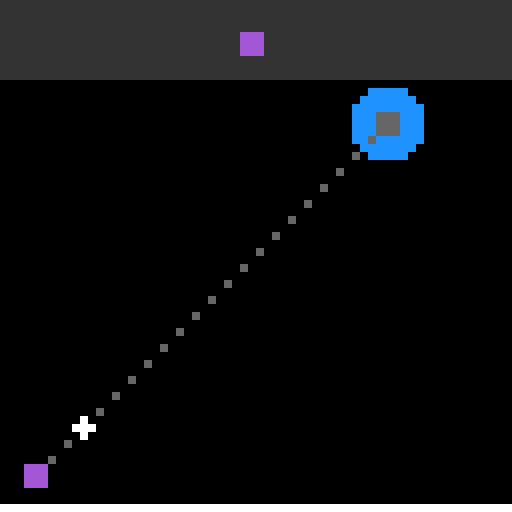

RAW VLM OUTPUT:
{
  "elements": [
    {
      "element": "blue circular object",
      "location": "top right",
      "role": "likely a target or collectible item",
      "confidence": "medium"
    },
    {
      "element": "white cross",
      "location": "bottom left",
      "role": "likely a player-controlled cursor or indicator",
      "confidence": "medium"
    },
    {
      "element": "purple squares",
      "location": "top center and bottom left",
      "role": "likely fixed obstacles or boundary markers",
      "confidence": "medium"
    },
    {
      "element": "dotted line",
      "location": "diagonal from bottom left to top right",
      "role": "likely a path or connection between elements",
      "confidence": "medium"
    }
  ],
  "player": {
    "element": "white cross",
    "why": "it is positioned at the bottom left and is distinct from other elements",
    "confidence": "medium"
  },
  "goal": {
    "element": "blue circular object",
    "why": "it is the only col

ValueError: Expected 2D grid, got shape=(0,)

In [36]:
# =========================
# Compact scene understanding over multiple steps
# =========================

import json
import torch
from IPython.display import display
from PIL import Image

SCENE_UNDERSTANDING_SYSTEM_PROMPT = """
You are analyzing an abstract 2D grid game screen.

Your job is to briefly identify the visible game elements and infer the likely game goal.
Do not choose an action.

Rules:
- Only mention objects that are clearly visible.
- Do not invent missing objects.
- Do not infer symmetric UI elements.
- Do not list tiny noise unless it seems important.
- For each element, say what it likely is in one short sentence.
- Separate observation from uncertainty.
- If unsure, say "unknown" rather than inventing a role.
- Do not describe objects as animals, faces, bodies, whales, fish, or creatures.

Return strict JSON only.
""".strip()


def generate_scene_understanding(processor, model, image, prompt, max_new_tokens=500):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {
                    "type": "text",
                    "text": SCENE_UNDERSTANDING_SYSTEM_PROMPT + "\n\n" + prompt,
                },
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
    )

    inputs = move_inputs_to_device(inputs, model_device(model))

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[-1]
    generated_ids = generated_ids[:, input_len:]

    return processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()


def build_compact_scene_prompt(raw_frame):
    grid = latest_grid_from_raw(raw_frame)
    meta = frame_metadata(raw_frame, game_id=CONFIG["GAME_ID"])

    return f"""
Analyze this current game screen.

Current metadata:
{json.dumps({
    "game_id": meta.get("game_id"),
    "state": meta.get("state"),
    "levels_completed": meta.get("levels_completed"),
    "available_actions": meta.get("available_actions"),
}, ensure_ascii=False)}

Detected connected color components:
{json.dumps(summarize_objects(grid, max_objects=16), ensure_ascii=False)}

Return JSON with this schema:
{{
  "elements": [
    {{
      "element": "short visible element name",
      "location": "approximate location",
      "role": "what this element likely is, in one sentence",
      "confidence": "low/medium/high"
    }}
  ],
  "player": {{
    "element": "most likely player or unknown",
    "why": "short reason",
    "confidence": "low/medium/high"
  }},
  "goal": {{
    "element": "most likely goal/target or unknown",
    "why": "short reason",
    "confidence": "low/medium/high"
  }},
  "game_objective_hypothesis": "one or two sentences describing what the player probably needs to do"
}}
""".strip()


def run_scene_understanding_probe(label="current"):
    raw_frame = SESSION["raw"]
    grid = latest_grid_from_raw(raw_frame)
    meta = frame_metadata(raw_frame, game_id=CONFIG["GAME_ID"])

    current_image = grid_to_rgb_array(
        grid,
        scale=CONFIG["IMAGE_SCALE"],
        draw_grid=False,
    )

    print("=" * 100)
    print(f"SCENE PROBE: {label}")
    print("metadata:")
    print(json.dumps({
        "state": meta.get("state"),
        "levels_completed": meta.get("levels_completed"),
        "available_actions": meta.get("available_actions"),
    }, ensure_ascii=False, indent=2))

    display(Image.fromarray(current_image))

    raw_scene_text = generate_scene_understanding(
        processor=processor,
        model=model,
        image=current_image,
        prompt=build_compact_scene_prompt(raw_frame),
        max_new_tokens=500,
    )

    print("RAW VLM OUTPUT:")
    print(raw_scene_text)

    try:
        parsed = extract_json_object(raw_scene_text)
        print("\nPARSED JSON:")
        print(json.dumps(parsed, ensure_ascii=False, indent=2))
        return parsed
    except Exception as e:
        print("\nFailed to parse JSON:", repr(e))
        return None


processor, model = get_or_load_vlm()

scene_probe_results = []

# 1. 현재 상태 먼저 분석
analysis = run_scene_understanding_probe("initial")
scene_probe_results.append({
    "step": "initial",
    "analysis": analysis,
})

# 2. 같은 게임에서 step_once()로 몇 단계 진행하면서 매번 분석
N_PROBE_STEPS = 5

for i in range(N_PROBE_STEPS):
    print("\n" + "#" * 100)
    print(f"RUNNING step_once #{i + 1}")
    print("#" * 100)

    record = step_once()

    print("ACTION RECORD:")
    print(json.dumps(record, ensure_ascii=False, indent=2, default=str))

    analysis = run_scene_understanding_probe(f"after step_once #{i + 1}")

    scene_probe_results.append({
        "step": i + 1,
        "record": record,
        "analysis": analysis,
    })

    raw_frame = SESSION["raw"]
    meta = frame_metadata(raw_frame, game_id=CONFIG["GAME_ID"])

    if meta.get("state") != "NOT_FINISHED":
        print(f"Stopping because state changed: {meta.get('state')}")
        break

print("\nDONE. scenEe_probe_results contains all analyses.")

# 원래 코드


In [ ]:
CONFIG["ACTIONS_PER_VLM_CALL"] = 3  # 1이면 기존처럼 한 스텝씩
CONFIG["STOP_SEQUENCE_ON_NO_CHANGE"] = True
CONFIG["STOP_SEQUENCE_ON_LEVEL_CHANGE"] = True

In [28]:
# =========================
# 7. Policy prompt
# =========================

POLICY_SYSTEM_PROMPT = """
You are playing an abstract 2D grid game made of colored geometric shapes.

You may receive one image or two images:
- If one image is provided, infer the current game state from it.
- If two images are provided, Image 1 is BEFORE the previous action and Image 2 is AFTER/current.

When two images are provided, your first job is to compare them.
Do not restart from scratch.
First identify what changed between Image 1 and Image 2:
- Which object moved?
- In what direction did it move?
- Which cells or shapes appeared, disappeared, or shifted?
- Did the previous action make meaningful progress or little/no progress?

The object or region that changed after the previous action is the strongest evidence for the controlled player.
Use visual change to update your player hypothesis.
Do not choose the next action until you have reasoned about the visual difference.

Controls:
ACTION1=up
ACTION2=down
ACTION3=left
ACTION4=right
ACTION5=interact/special
ACTION6=x,y coordinate
ACTION7=extra

Do not describe the image as a character, animal, face, body, whale, fish, or creature.

Return strict JSON only:
{
  "visual_change": "what changed from Image 1 to Image 2, or 'only one image' if no previous image",
  "player_hypothesis": "which object is likely controlled and why",
  "progress_assessment": "progress / no_progress / uncertain",
  "reasoning": "brief reason for the next action",
  "chosen_actions": ["ACTION1"]
}
""".strip()

ALL_ARC_ACTIONS = [
    "RESET",
    "ACTION1",
    "ACTION2",
    "ACTION3",
    "ACTION4",
    "ACTION5",
    "ACTION6",
    "ACTION7",
]

def compact_transition_for_prompt(t):
    if not isinstance(t, dict):
        return None

    return {
        "changed_cells": t.get("changed_cells"),
        "changed_bbox": t.get("changed_bbox"),
        "levels_completed": t.get("levels_completed"),
        "state": t.get("state"),
    }


def build_policy_prompt(meta, grid=None):
    current_available = list(meta.get("available_actions", []))
    max_actions = int(CONFIG.get("ACTIONS_PER_VLM_CALL", 1))

    prev_reasoning = SESSION.get("last_vlm_reasoning")
    prev_visual_change = SESSION.get("last_visual_change")
    prev_player_hypothesis = SESSION.get("last_player_hypothesis")
    prev_action = SESSION.get("last_action")
    prev_transition = compact_transition_for_prompt(SESSION.get("last_transition"))

    if prev_action or prev_transition:
        previous_context = f"""
Previous action:
{prev_action or "(none)"}

Previous VLM visual_change:
{prev_visual_change or "(none)"}

Previous VLM player_hypothesis:
{prev_player_hypothesis or "(none)"}

Previous reasoning:
{prev_reasoning or "(none)"}

Numeric outcome of previous action:
{json.dumps(prev_transition, ensure_ascii=False)}

Important:
- The numeric outcome is only a hint.
- The main evidence is the visual difference between Image 1 and Image 2.
- If Image 1 and Image 2 are provided, compare them before choosing an action.
- If the changed region moved after the previous action, that changed region is likely the controlled player.
- If the previous action caused little/no meaningful visual change, do not blindly repeat it.
""".strip()
    else:
        previous_context = """
No previous action is available.
Infer the player and goal from the current image.
""".strip()

    return f"""
Available actions:
{json.dumps(current_available, ensure_ascii=False)}

{previous_context}

Image task:
- If two images are provided, Image 1 is BEFORE the previous action and Image 2 is AFTER/current.
- First describe the visual difference.
- Use the visual difference to identify or revise the player hypothesis.
- Then choose the next action.

Rules:
- Return strict JSON only.
- chosen_actions must be a list.
- Output 1 to {max_actions} actions.
- Every action must be exactly one of Available actions.
- Do not choose an action before comparing the images when two images are provided.
- Do not rely only on object appearance to decide the player.
- Prefer the object/region that changed after the previous action as the player.
- If the previous action made little/no progress, test a different action or hypothesis.

Current metadata:
{json.dumps({
    "state": meta.get("state"),
    "levels_completed": meta.get("levels_completed"),
    "available_actions": meta.get("available_actions"),
}, ensure_ascii=False)}

Return only:
{{
  "visual_change": "...",
  "player_hypothesis": "...",
  "progress_assessment": "progress / no_progress / uncertain",
  "reasoning": "...",
  "chosen_actions": []
}}
""".strip()

# =========================
# 7.5 VLM generation / JSON parsing helpers
# =========================

def model_device(model):
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def move_inputs_to_device(inputs, device):
    out = {}
    for k, v in inputs.items():
        if hasattr(v, "to"):
            out[k] = v.to(device)
        else:
            out[k] = v
    return out


def prepare_qwen3vl_inputs(processor, images, prompt):
    full_text = POLICY_SYSTEM_PROMPT + "\n\n" + prompt

    messages = [
        {
            "role": "user",
            "content": [{"type": "image"} for _ in images] + [
                {"type": "text", "text": full_text}
            ],
        }
    ]

    # Some Qwen3VLProcessor versions fail if images= is passed to apply_chat_template.
    # So we only use apply_chat_template to build text, then pass images to processor().
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    return processor(
        text=[text],
        images=images,
        return_tensors="pt",
    )

def generate_local_vlm(processor, model, images, prompt, max_new_tokens=None):
    max_new_tokens = int(max_new_tokens or CONFIG["MAX_NEW_TOKENS"])

    inputs = prepare_qwen3vl_inputs(processor, images, prompt)
    inputs = move_inputs_to_device(inputs, model_device(model))

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[-1]
    generated_ids = generated_ids[:, input_len:]

    return processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()


def extract_json_object(text):
    text = (text or "").strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    text2 = re.sub(r"^```(?:json)?\s*", "", text)
    text2 = re.sub(r"\s*```$", "", text2)
    try:
        return json.loads(text2)
    except Exception:
        pass

    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            pass

    raise ValueError(f"No JSON object found in VLM output:\n{text}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-05-23 07:41:49 | INFO | Successfully fetched 25 environment(s) from API
2026-05-23 07:41:49 | INFO | Created new scorecard: 129efe79-1a76-4496-861f-8bacfe076eb6
2026-05-23 07:41:50 | INFO | Successfully fetched metadata for game su15
2026-05-23 07:41:50 | INFO | Recording to /kaggle/working/recordings/129efe79-1a76-4496-861f-8bacfe076eb6/su15-1944f8ab-d8853066-6d61-4879-8cf8-710cc7f280e0.jsonl
2026-05-23 07:41:50 | INFO | Successfully reset game su15-1944f8ab, guid=d8853066-6d61-4879-8cf8-710cc7f280e0, scorecard_id=129efe79-1a76-4496-861f-8bacfe076eb6
2026-05-23 07:41:50 | INFO | Recording to /kaggle/working/recordings/129efe79-1a76-4496-861f-8bacfe076eb6/su15-1944f8ab-d8853066-6d61-4879-8cf8-710cc7f280e0.jsonl
2026-05-23 07:41:50 | INFO | Successfully reset game su15-1944f8ab, guid=d8853066-6d61-4879-8cf8-710cc7f280e0, scorecard_id=129efe79-1a76-4496-861f-8bacfe076eb6
arc_mo

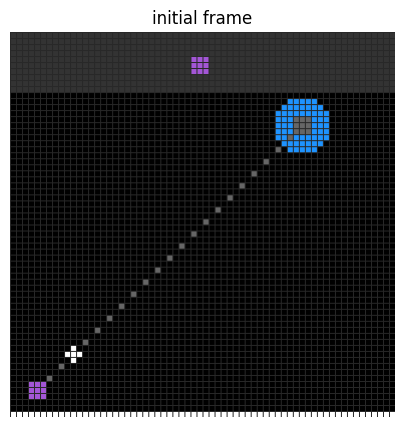

{'arcade': <arc_agi.base.Arcade at 0x7e75013c6990>,
 'wrapper': <arc_agi.remote_wrapper.RemoteEnvironmentWrapper at 0x7e75013af890>,
 'scorecard_id': '129efe79-1a76-4496-861f-8bacfe076eb6',
 'raw': FrameDataRaw(game_id='su15-1944f8ab', state=<GameState.NOT_FINISHED: 'NOT_FINISHED'>, levels_completed=0, win_levels=9, action_input=ActionInput(id=<GameAction.RESET: 0>, data={'game_id': 'su15-1944f8ab'}, reasoning=None), guid='d8853066-6d61-4879-8cf8-710cc7f280e0', full_reset=False, available_actions=[6, 7]),
 'prev_grid': None,
 'last_action': None,
 'last_transition': None,
 'logs': [],
 'closed': False,
 'memory': {'actions': {'ACTION1': 'move up',
   'ACTION2': 'move down',
   'ACTION3': 'move left',
   'ACTION4': 'move right',
   'ACTION5': 'interact/select/wait/special'},
  'rules': {}},
 'action_queue': [],
 'current_plan': None,
 'current_plan_raw_output': ''}

In [29]:
# =========================
# 9. ARC session
# =========================

DEFAULT_MEMORY = {
    "actions": {
        "ACTION1": "move up",
        "ACTION2": "move down",
        "ACTION3": "move left",
        "ACTION4": "move right",
        "ACTION5": "interact/select/wait/special",
    },
    "rules": {},
}


SESSION = {
    "arcade": None,
    "wrapper": None,
    "scorecard_id": None,
    "raw": None,
    "prev_grid": None,
    "last_action": None,
    "last_transition": None,
    "logs": [],
    "closed": False,
    "memory": json.loads(json.dumps(DEFAULT_MEMORY)),

    # multi-action planning
    "action_queue": [],
    "current_plan": None,
    "current_plan_raw_output": "",
}


def start_arc_session():
    from arc_agi import Arcade, OperationMode

    mode = CONFIG["ARC_MODE"].lower()
    if mode in {"online", "competition"} and not CONFIG["ARC_API_KEY"]:
        raise ValueError("ARC_API_KEY is required for online/competition mode.")

    arcade = Arcade(
        arc_api_key=CONFIG["ARC_API_KEY"] or "test-key-123",
        arc_base_url=CONFIG["ARC_BASE_URL"],
        operation_mode=OperationMode(mode),
        environments_dir=CONFIG["ENVIRONMENTS_DIR"],
        recordings_dir=CONFIG["RECORDINGS_DIR"],
    )

    scorecard_id = arcade.create_scorecard(
        source_url="vlm-policy-multi-action-visual-transition",
        tags=["vlm-only", "qwen3-vl", "multi-action", "visual-transition"],
    )

    wrapper = arcade.make(
        CONFIG["GAME_ID"],
        scorecard_id=scorecard_id,
        save_recording=CONFIG["SAVE_RECORDING"],
        include_frame_data=True,
        render_mode=None,
    )

    raw = wrapper.reset()
    SESSION.update({
        "arcade": arcade,
        "wrapper": wrapper,
        "scorecard_id": scorecard_id,
        "raw": raw,
        "prev_grid": None,
        "last_action": None,
        "last_transition": None,
        "logs": [],
        "closed": False,
        "memory": json.loads(json.dumps(DEFAULT_MEMORY)),

        # multi-action planning
        "action_queue": [],
        "current_plan": None,
        "current_plan_raw_output": "",
    })

    print("arc_mode:", mode)
    print("scorecard_id:", scorecard_id)
    print("scorecard_url:", f"{CONFIG['ARC_BASE_URL'].rstrip('/')}/scorecards/{scorecard_id}")
    print("initial_meta:")
    pprint(frame_metadata(raw, game_id=CONFIG["GAME_ID"]))
    display_grid(latest_grid_from_raw(raw), title="initial frame")
    return SESSION


def close_scorecard():
    if SESSION.get("closed"):
        print("scorecard already closed")
        return None

    arcade = SESSION.get("arcade")
    scorecard_id = SESSION.get("scorecard_id")
    if arcade is None or scorecard_id is None:
        print("no active scorecard")
        return None

    try:
        summary = arcade.close_scorecard(scorecard_id)
    except Exception as exc:
        print("close_scorecard failed:", repr(exc))
        summary = None

    SESSION["closed"] = True
    print("scorecard_id:", scorecard_id)
    print("scorecard_url:", f"{CONFIG['ARC_BASE_URL'].rstrip('/')}/scorecards/{scorecard_id}")

    if summary is not None:
        Path(CONFIG["SUMMARY_PATH"]).write_text(
            json.dumps(summary, ensure_ascii=False, indent=2, default=str),
            encoding="utf-8",
        )
        print("wrote summary:", CONFIG["SUMMARY_PATH"])
        pprint(summary)

    return summary


start_arc_session()

In [35]:
# =========================
# 8. Action parsing and memory
# =========================

def normalize_chosen_action_text(action_text):
    action_text = str(action_text).strip()
    if not action_text:
        raise ValueError("empty action")

    if re.fullmatch(r"[0-9]+", action_text):
        return f"ACTION{action_text}"

    if re.match(r"^[0-9]+\|", action_text):
        n, rest = action_text.split("|", 1)
        return f"ACTION{n}|{rest}"

    m = re.match(r"(?i)^action\s*([0-9]+)(.*)$", action_text)
    if m:
        return f"ACTION{m.group(1)}{m.group(2)}".replace(" ", "")

    return action_text


def action_base_name(action_text):
    return normalize_chosen_action_text(action_text).split("|", 1)[0]


def validate_action_text(action_text, raw_frame):
    action_text = normalize_chosen_action_text(action_text)

    if "|" in action_text:
        name, payload_text = action_text.split("|", 1)
    else:
        name, payload_text = action_text, ""

    allowed = available_action_names(raw_frame)
    if name not in allowed:
        raise ValueError(f"{name} not in available_actions={allowed}")

    if name == "ACTION6" and payload_text:
        grid = latest_grid_from_raw(raw_frame)
        arr = np.asarray(grid)
        h, w = arr.shape[:2]

        parts = {}
        for item in payload_text.split(","):
            if "=" not in item:
                continue
            k, v = item.split("=", 1)
            parts[k.strip()] = int(v)

        x = parts.get("x")
        y = parts.get("y")
        if x is None or y is None:
            raise ValueError("ACTION6 payload must include x and y")
        if not (0 <= x < w and 0 <= y < h):
            raise ValueError(f"ACTION6 coordinate out of bounds: x={x}, y={y}, grid={w}x{h}")

    return action_text


def parse_action(action_text):
    from arcengine import GameAction

    action_text = normalize_chosen_action_text(action_text)
    if "|" not in action_text:
        return GameAction.from_name(action_text), None

    name, payload_text = action_text.split("|", 1)
    payload = {}
    for part in payload_text.split(","):
        if not part.strip():
            continue
        key, value = part.split("=", 1)
        payload[key.strip()] = int(value)
    return GameAction.from_name(name), payload


def get_chosen_actions_from_parsed(parsed, raw_frame):
    """
    Supports:
    - {"chosen_actions": ["ACTION1", "ACTION4"]}
    - {"chosen_action": "ACTION1"}
    - {"decision": {"chosen_action": "ACTION1"}}
    """
    max_n = int(CONFIG.get("ACTIONS_PER_VLM_CALL", 1))

    if not isinstance(parsed, dict):
        raise ValueError(f"parsed output is not dict: {parsed}")

    actions = parsed.get("chosen_actions")

    if actions is None and parsed.get("chosen_action"):
        actions = [parsed.get("chosen_action")]

    if actions is None:
        decision = parsed.get("decision")
        if isinstance(decision, dict) and decision.get("chosen_action"):
            actions = [decision.get("chosen_action")]

    if isinstance(actions, str):
        actions = [actions]

    if not isinstance(actions, list):
        raise ValueError(f"No chosen_actions found in parsed output: {parsed}")

    clean = []
    for a in actions:
        if len(clean) >= max_n:
            break
        clean.append(validate_action_text(a, raw_frame))

    if not clean:
        raise ValueError(f"Empty chosen_actions after validation: {parsed}")

    return clean


def summarize_transition(before_grid, after_grid, after_raw=None):
    before = np.asarray(as_list_grid(before_grid), dtype=int)
    after = np.asarray(as_list_grid(after_grid), dtype=int)

    out = {
        "changed_cells": None,
        "changed_bbox": None,
        "color_changes": [],
        "state": None,
        "levels_completed": None,
    }

    if after_raw is not None:
        state = getattr(after_raw, "state", None)
        out["state"] = getattr(state, "name", str(state)) if state is not None else None
        out["levels_completed"] = getattr(after_raw, "levels_completed", None)

    if before.shape != after.shape or not before.size:
        out["changed_cells"] = "shape_changed"
        return out

    diff = before != after
    out["changed_cells"] = int(diff.sum())

    if diff.any():
        ys, xs = np.where(diff)
        out["changed_bbox"] = {
            "x_min": int(xs.min()),
            "x_max": int(xs.max()),
            "y_min": int(ys.min()),
            "y_max": int(ys.max()),
        }

        pairs = {}
        for b, a in zip(before[diff].tolist(), after[diff].tolist()):
            key = (int(b), int(a))
            pairs[key] = pairs.get(key, 0) + 1

        out["color_changes"] = [
            {"from": int(k[0]), "to": int(k[1]), "count": int(v)}
            for k, v in sorted(pairs.items(), key=lambda item: -item[1])[:8]
        ]

    return out


def update_action_memory_from_vlm(plan):
    """
    ACTION1-ACTION4 directions are fixed.
    Do not store the full reasoning paragraph under an action.
    """
    return


def update_rule_memory_from_vlm(plan):
    return


def fallback_action(raw_frame):
    allowed = available_action_names(raw_frame)
    if not allowed:
        raise ValueError("no available actions")

    recent = [
        r.get("action")
        for r in SESSION.get("logs", [])[-6:]
        if isinstance(r, dict)
    ]

    for a in allowed:
        if a not in recent:
            return a

    return allowed[0]

In [31]:
# =========================
# 10. Multi-action VLM policy
# =========================

def images_for_current_query(raw_frame):
    current_grid = latest_grid_from_raw(raw_frame)
    current_image = grid_to_rgb_array(
        current_grid,
        scale=CONFIG["IMAGE_SCALE"],
        draw_grid=CONFIG["DRAW_GRID"],
    )

    prev_grid = SESSION.get("prev_grid")
    last_action = SESSION.get("last_action")

    if prev_grid is not None and last_action is not None:
        prev_image = grid_to_rgb_array(
            prev_grid,
            scale=CONFIG["IMAGE_SCALE"],
            draw_grid=CONFIG["DRAW_GRID"],
        )
        return [prev_image, current_image]

    return [current_image]


def ask_vlm_for_action_sequence(raw_frame):
    grid = latest_grid_from_raw(raw_frame)
    images = images_for_current_query(raw_frame)
    meta = frame_metadata(raw_frame, game_id=CONFIG["GAME_ID"])
    prompt = build_policy_prompt(meta=meta, grid=grid)

    processor, model = get_or_load_vlm()
    raw_text = generate_local_vlm(
        processor=processor,
        model=model,
        images=images,
        prompt=prompt,
        max_new_tokens=CONFIG["MAX_NEW_TOKENS"],
    )

    parsed = extract_json_object(raw_text)
    SESSION["last_vlm_reasoning"] = str(parsed.get("reasoning", "")).strip()
    update_rule_memory_from_vlm(parsed)

    action_texts = get_chosen_actions_from_parsed(parsed, raw_frame)
    return action_texts, parsed, raw_text


def should_clear_action_queue(raw_before, raw_after, transition):
    old_levels = getattr(raw_before, "levels_completed", None)
    new_levels = getattr(raw_after, "levels_completed", None)

    if CONFIG.get("STOP_SEQUENCE_ON_LEVEL_CHANGE", True):
        if old_levels != new_levels:
            return True, "levels_completed changed"

    if CONFIG.get("STOP_SEQUENCE_ON_NO_CHANGE", True):
        if transition.get("changed_cells") == 0:
            return True, "no visible change"

    if CONFIG.get("STOP_SEQUENCE_ON_ACTIONS_CHANGE", True):
        if available_action_names(raw_before) != available_action_names(raw_after):
            return True, "available_actions changed"

    return False, ""
def infer_test_result(raw_before, raw_after, transition, plan):
    old_level = getattr(raw_before, "levels_completed", None)
    new_level = getattr(raw_after, "levels_completed", None)

    if old_level != new_level:
        return "confirmed_progress"

    if transition.get("changed_cells") == 0:
        return "no_visible_effect"

    if transition.get("changed_cells") <= 2:
        return "weak_or_blocked_effect"

    return "visible_change_no_progress"

def step_once(display_after=True):
    raw = SESSION.get("raw")
    wrapper = SESSION.get("wrapper")
    if raw is None or wrapper is None:
        raise RuntimeError("No active session. Run start_arc_session() first.")

    before_grid = latest_grid_from_raw(raw)
    vlm_called = False
    raw_vlm_output = ""
    queue_before = list(SESSION.get("action_queue", []))

    if not SESSION.get("action_queue"):
        try:
            action_texts, plan, raw_vlm_output = ask_vlm_for_action_sequence(raw)
            SESSION["action_queue"] = list(action_texts)
            SESSION["current_plan"] = plan
            SESSION["current_plan_raw_output"] = raw_vlm_output
            vlm_called = True
        except Exception as exc:
            print("VLM action parse/validation failed:", repr(exc))
            fallback = fallback_action(raw)
            plan = {
                "reasoning": f"fallback due to error: {repr(exc)}",
                "chosen_actions": [fallback],
            }
            SESSION["action_queue"] = [fallback]
            SESSION["current_plan"] = plan
            SESSION["current_plan_raw_output"] = ""
            raw_vlm_output = ""
            vlm_called = True
    else:
        plan = SESSION.get("current_plan") or {
            "reasoning": "continuing queued VLM action sequence",
            "chosen_actions": list(SESSION.get("action_queue", [])),
        }

    action_text = SESSION["action_queue"].pop(0)

    action, payload = parse_action(action_text)
    after_raw = wrapper.step(action, data=payload)
    after_grid = latest_grid_from_raw(after_raw)
    transition = summarize_transition(before_grid, after_grid, after_raw=after_raw)
    test_result = infer_test_result(raw, after_raw, transition, plan)
    

    clear_queue, clear_reason = should_clear_action_queue(raw, after_raw, transition)
    if clear_queue:
        SESSION["action_queue"] = []

    record = {
        "step": len(SESSION["logs"]),
        "action": action_text,
        "vlm_called": vlm_called,
        "plan": plan,
        "planned_actions": plan.get("chosen_actions") if isinstance(plan, dict) else None,
        "queue_before": queue_before,
        "queue_after": list(SESSION.get("action_queue", [])),
        "queue_cleared": clear_queue,
        "queue_clear_reason": clear_reason,
        "transition_numeric": transition,
        "memory": dict(SESSION["memory"]),
        "before_meta": frame_metadata(raw, game_id=CONFIG["GAME_ID"]),
        "after_meta": frame_metadata(after_raw, game_id=CONFIG["GAME_ID"]),
        "raw_vlm_output": raw_vlm_output if vlm_called else "",
        "test_goal": plan.get("test_goal") if isinstance(plan, dict) else None,
        "test_result": test_result,
    }

    SESSION["prev_grid"] = before_grid
    SESSION["last_action"] = action_text
    SESSION["last_transition"] = transition
    SESSION["logs"].append(record)
    SESSION["raw"] = after_raw

    with open(CONFIG["LOG_PATH"], "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False, default=str) + "\n")

    reasoning = plan.get("reasoning") if isinstance(plan, dict) else None

    print("=" * 80)
    print("step:", record["step"])
    print("vlm_called:", vlm_called)
    print("action:", action_text)
    print("planned_actions:", record["planned_actions"])
    print("queue_after:", record["queue_after"])
    if clear_queue:
        print("queue_cleared:", clear_reason)
    print("reasoning:", reasoning)
    print("numeric transition:")
    pprint(transition)
    print("memory:")
    pprint(SESSION["memory"])

    if display_after:
        display_grid(after_grid, title=f"after {action_text}")

    return record

In [33]:
# =========================
# 11. Multi-step loop
# =========================

def is_terminal_raw(raw_frame):
    state = getattr(raw_frame, "state", None)
    state_name = getattr(state, "name", str(state)) if state is not None else ""
    state_name = str(state_name).upper()
    if state_name in {"WIN", "GAME_OVER", "DONE"}:
        return True
    if getattr(raw_frame, "won", False):
        return True
    return False


def run_vlm_episode(max_steps=None, close_at_end=False, display_after=True):
    max_steps = int(max_steps or CONFIG["MAX_STEPS"])
    logs = []

    for _ in range(max_steps):
        record = step_once(display_after=display_after)
        logs.append(record)

        if is_terminal_raw(SESSION["raw"]):
            print("terminal state reached")
            break

    print("wrote logs:", CONFIG["LOG_PATH"])
    print("remaining action_queue:", SESSION.get("action_queue", []))

    if close_at_end:
        close_scorecard()

    return logs

In [34]:
CONFIG["ACTIONS_PER_VLM_CALL"] = 3
logs = run_vlm_episode(max_steps=30, display_after=True)

using cached VLM: /kaggle/input/models/qwen-lm/qwen-3-vl/transformers/8b-instruct/1


KeyboardInterrupt: 

In [ ]:
# =========================
# 12. Inspect logs / close scorecard
# =========================

def read_jsonl(path=None, limit=5):
    path = Path(path or CONFIG["LOG_PATH"])
    if not path.exists():
        print("no log file:", path)
        return []
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    print("rows:", len(rows))
    return rows[-limit:]

# recent = read_jsonl(limit=3)
# pprint(recent[-1] if recent else None)
# summary = close_scorecard()